# Raceline Optimization — two methods, one scorer

Builds a minimum-curvature raceline from `centerline_full.csv` **two different
ways**, scores both under an identical model, and exports both.

| Method | Solver | Notes |
|---|---|---|
| **A — scipy** | `scipy.optimize.lsq_linear` | Hand-rolled. Bound-constrained least squares, no extra dependencies. |
| **B — TUM** | `tph.opt_min_curv` | TUM's real QP. Enforces `kappa_bound` as a hard constraint and puts vehicle width inside the solve. |

Both are the same underlying idea — push each centerline point sideways along its
normal to minimise curvature, subject to staying on track — so they should agree.
Where they do not is informative.

## Why both are kept

On this track they land within ~2.5% of each other, and **A is currently the
faster of the two**. Neither dominates:

- **A** produces a slightly lower peak and mean curvature here, which is what
  actually sets corner speed.
- **B** enforces the steering limit as a hard constraint and accounts for vehicle
  width inside the QP, so it cannot silently emit a line the car is unable to
  follow. That safety matters more on a wider or faster track.

Since the gap is smaller than the uncertainty in `A_LAT_MAX` (a guess), picking a
winner from the numbers alone would be false precision. Run both on the car.

## Two gotchas, both discovered the hard way

**`tph.iqp_handler` never returns on this track.** Its loop is `while True`,
exiting only when linearisation error falls below tolerance. Here that error sits
around 4.5 and never converges — the tool assumes full-size circuits with 20 m
radii, while yours are ~1 m, so a 0.9 m lateral move is comparable to the local
radius. Method B replaces it with a bounded loop.

**`tph` normals point RIGHT**, opposite to the left-normal convention used in
`raceline_experiments.ipynb` (verified: mean dot product −1.000). Method B swaps
the width columns; method A does not. Getting this backwards lets the solver push
the line into space that is not there.

In [1]:
from pathlib import Path

import numpy as np
from scipy.optimize import lsq_linear
from scipy import interpolate
import trajectory_planning_helpers as tph
import matplotlib.pyplot as plt
import yaml

RACELINE_DIR = Path.home() / "Documents/roboracer/raceline"
MAP = Path.home() / "Documents/roboracer/devkit_ws/src/racer_mapping/maps/track_clean"

# --- vehicle (published competition spec) ---
VEHICLE_WIDTH = 0.27
WHEELBASE     = 0.324
MAX_STEER     = 0.5236
MASS          = 3.906

KAPPA_CAR   = np.tan(MAX_STEER) / WHEELBASE     # 1.78 1/m mechanical limit
KAPPA_BOUND = 0.85 * KAPPA_CAR                  # leave the follower headroom

SAFETY_MARGIN = 0.10        # [m] beyond half the car width
MAX_ITERS     = 8

# --- method A (scipy) ---
A_LAMBDA   = 2.0            # roughness penalty on lateral offsets
A_SPLINE_S = 0.20           # smoothing when re-fitting each iteration

# --- method B (TUM) ---
B_STEPSIZE = 0.10           # [m] raceline resolution

# --- shared speed model ---
# A_LAT_MAX is a GUESS. It sets every absolute lap time below and dominates the
# difference between the two methods. Measure it on the car.
A_LAT_MAX  = 6.0
A_LONG_MAX = 5.0
V_MAX      = 8.0
DRAG_COEFF = 0.05
DYN_MODEL_EXP = 2.0         # 2.0 = traction ellipse

/home/theflash/Documents/roboracer/.venv-rl/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


## 1. Centerline

In [2]:
D = np.loadtxt(RACELINE_DIR / "centerline_full.csv", delimiter=",")
cx, cy, psi_c, w_right, w_left = D[:, 1], D[:, 2], D[:, 3], D[:, 5], D[:, 6]
N = len(cx)

print(f"{N} points")
print(f"width after {SAFETY_MARGIN} m margin: "
      f"min {(w_left+w_right).min()-2*SAFETY_MARGIN:.2f} m, "
      f"median {np.median(w_left+w_right)-2*SAFETY_MARGIN:.2f} m")
print(f"kappa: bound {KAPPA_BOUND:.2f}, car limit {KAPPA_CAR:.2f} 1/m")

400 points
width after 0.1 m margin: min 0.82 m, median 1.20 m
kappa: bound 1.51, car limit 1.78 1/m


## 2. The scorer

**One function judges every line.** This is the part that makes the comparison
meaningful: curvature is re-derived the same way (tph splines) and the velocity
profile uses the same g-g diagram, regardless of which solver produced the points.

An earlier version of this notebook scored the two methods with different
velocity models and reported a difference that was mostly the model, not the line.

In [3]:
ggv = np.array([[0.0, A_LONG_MAX, A_LAT_MAX],
                [V_MAX, A_LONG_MAX, A_LAT_MAX]])
ax_max_machines = np.array([[0.0, A_LONG_MAX], [V_MAX, A_LONG_MAX]])


def score(x, y, label=""):
    '''Curvature + velocity profile + lap time for any closed line.'''
    closed = np.vstack([np.column_stack([x, y]), [x[0], y[0]]])
    coeffs_x, coeffs_y, _, _ = tph.calc_splines.calc_splines(path=closed)
    el = tph.calc_spline_lengths.calc_spline_lengths(coeffs_x=coeffs_x, coeffs_y=coeffs_y)
    _, kappa = tph.calc_head_curv_an.calc_head_curv_an(
        coeffs_x=coeffs_x, coeffs_y=coeffs_y, ind_spls=np.arange(len(coeffs_x)),
        t_spls=np.zeros(len(coeffs_x)), calc_curv=True)

    vx = tph.calc_vel_profile.calc_vel_profile(
        ax_max_machines=ax_max_machines, kappa=kappa, el_lengths=el, closed=True,
        drag_coeff=DRAG_COEFF, m_veh=MASS, ggv=ggv,
        dyn_model_exp=DYN_MODEL_EXP, mu=None, v_max=V_MAX)

    # calc_ax/t_profile want one more speed sample than segments.
    vx_open = np.append(vx, vx[0])
    ax = tph.calc_ax_profile.calc_ax_profile(vx_profile=vx_open, el_lengths=el,
                                             eq_length_output=False)
    t = float(tph.calc_t_profile.calc_t_profile(vx_profile=vx_open, ax_profile=ax,
                                                el_lengths=el)[-1])
    return dict(label=label, x=x, y=y, kappa=kappa, el=el, vx=vx, t=t,
                length=float(el.sum()), kmax=float(np.abs(kappa).max()),
                kmean=float(np.abs(kappa).mean()))


base = score(cx, cy, "centerline")
print(f"centerline: {base['length']:.2f} m, |k|max {base['kmax']:.3f}, lap {base['t']:.3f} s")

centerline: 30.93 m, |k|max 0.923, lap 7.580 s


## 3. Method A — scipy

Each point moves to $p_i = c_i + \alpha_i n_i$. For roughly uniform spacing,
curvature is proportional to the second difference $p_{i-1}-2p_i+p_{i+1}$, which
is **linear in** $\alpha$ — so this is bound-constrained least squares.

$S$ penalises roughness in $\alpha$; without it the offsets go jagged and the
line fills with kinks. The loop re-fits a spline each pass because the normals
move once the points do, and keeps the best iterate — the re-linearisation is not
a contraction and successive iterates oscillate.

In [4]:
def solve_scipy(lam=A_LAMBDA, smooth=A_SPLINE_S, iters=MAX_ITERS):
    i = np.arange(N)
    im, ip = (i - 1) % N, (i + 1) % N
    margin = VEHICLE_WIDTH / 2 + SAFETY_MARGIN
    lo, hi = -(w_right - margin), (w_left - margin)
    mid = (lo + hi) / 2
    lo, hi = np.where(lo > hi, mid - 1e-3, lo), np.where(lo > hi, mid + 1e-3, hi)

    S = np.zeros((N, N))
    S[i, im], S[i, i], S[i, ip] = 1.0, -2.0, 1.0

    bx, by, bpsi = cx.copy(), cy.copy(), psi_c.copy()
    best = None
    for it in range(iters):
        nx, ny = -np.sin(bpsi), np.cos(bpsi)          # LEFT normal
        A = np.zeros((2 * N, N))
        A[i, im] += nx[im];      A[i, i] += -2 * nx[i];      A[i, ip] += nx[ip]
        A[N + i, im] += ny[im];  A[N + i, i] += -2 * ny[i];  A[N + i, ip] += ny[ip]
        b = np.concatenate([bx[im] - 2 * bx[i] + bx[ip],
                            by[im] - 2 * by[i] + by[ip]])

        alpha = lsq_linear(np.vstack([A, np.sqrt(lam) * S]),
                           np.concatenate([-b, np.zeros(N)]),
                           bounds=(lo, hi), max_iter=400).x

        # offsets always measured from the FIXED centerline, so they cannot drift
        tck, _ = interpolate.splprep([cx - alpha * np.sin(psi_c),
                                      cy + alpha * np.cos(psi_c)], s=smooth, per=True)
        u = np.linspace(0, 1, N, endpoint=False)
        bx, by = (np.asarray(v) for v in interpolate.splev(u, tck))
        dx, dy = interpolate.splev(u, tck, der=1)
        bpsi = np.arctan2(dy, dx)

        r = score(bx, by, "A-scipy")
        ok = r["kmax"] <= KAPPA_CAR
        keep = ok and (best is None or r["t"] < best["t"])
        if keep:
            best = r
        print(f"  iter {it}: |k|max {r['kmax']:.3f}  len {r['length']:.2f} m  "
              f"lap {r['t']:.3f} s{'  <- best' if keep else ''}")
    return best


print("method A (scipy):")
res_a = solve_scipy()

method A (scipy):


  iter 0: |k|max 1.341  len 27.64 m  lap 6.815 s  <- best


  iter 1: |k|max 1.041  len 28.34 m  lap 6.949 s


  iter 2: |k|max 0.999  len 27.72 m  lap 6.813 s  <- best


  iter 3: |k|max 1.363  len 27.81 m  lap 6.930 s


  iter 4: |k|max 1.049  len 28.34 m  lap 6.946 s


  iter 5: |k|max 0.998  len 27.72 m  lap 6.815 s


  iter 6: |k|max 1.364  len 27.81 m  lap 6.930 s


  iter 7: |k|max 1.049  len 28.35 m  lap 6.946 s


## 4. Method B — TUM

`tph.opt_min_curv` is the real QP: `kappa_bound` is a hard constraint and
`w_veh` keeps the *car* inside the walls rather than its centre point.

Each pass re-centres the reference on the resulting line and shrinks the
remaining width by how far it moved — that is what makes the next
linearisation valid. Bounded at `MAX_ITERS`, unlike `tph.iqp_handler`.

In [5]:
def solve_tum(stepsize=B_STEPSIZE, iters=MAX_ITERS):
    rs = lambda v, n: np.interp(np.linspace(0, 1, n), np.linspace(0, 1, len(v)), v)
    # SWAPPED: tph normals point right, ours point left.
    track = np.column_stack([cx, cy,
                             np.maximum(w_left - SAFETY_MARGIN, 0.01),
                             np.maximum(w_right - SAFETY_MARGIN, 0.01)])
    best = None
    for it in range(iters):
        closed = np.vstack([track[:, :2], track[0, :2]])
        _, _, A, normvec = tph.calc_splines.calc_splines(path=closed)

        alpha, curv_err = tph.opt_min_curv.opt_min_curv(
            reftrack=track, normvectors=normvec, A=A,
            kappa_bound=KAPPA_BOUND, w_veh=VEHICLE_WIDTH,
            print_debug=False, plot_debug=False, closed=True)

        rl, *_ = tph.create_raceline.create_raceline(
            refline=track[:, :2], normvectors=normvec, alpha=alpha,
            stepsize_interp=stepsize)

        r = score(rl[:, 0], rl[:, 1], "B-TUM")
        ok = r["kmax"] <= KAPPA_CAR
        keep = ok and (best is None or r["t"] < best["t"])
        if keep:
            best = r
        print(f"  iter {it}: curv_err {curv_err:7.4f}  |k|max {r['kmax']:.3f}  "
              f"len {r['length']:.2f} m  lap {r['t']:.3f} s{'  <- best' if keep else ''}")

        n = len(rl)
        a_i = rs(alpha, n)
        track = np.column_stack([rl[:, 0], rl[:, 1],
                                 np.maximum(rs(track[:, 2], n) - a_i, 0.02),
                                 np.maximum(rs(track[:, 3], n) + a_i, 0.02)])
    return best


print("method B (TUM):")
res_b = solve_tum()

method B (TUM):


  iter 0: curv_err  4.6934  |k|max 5.335  len 27.50 m  lap 7.698 s


  iter 1: curv_err  1.9121  |k|max 1.471  len 27.66 m  lap 7.206 s  <- best


  iter 2: curv_err  0.2478  |k|max 1.668  len 27.50 m  lap 7.195 s  <- best


  iter 3: curv_err  0.1622  |k|max 1.254  len 27.55 m  lap 7.089 s  <- best


  iter 4: curv_err  0.0996  |k|max 1.139  len 27.57 m  lap 7.127 s


  iter 5: curv_err  0.0550  |k|max 1.098  len 27.53 m  lap 7.020 s  <- best


  iter 6: curv_err  0.0536  |k|max 1.063  len 27.58 m  lap 7.088 s


  iter 7: curv_err  0.0486  |k|max 1.069  len 27.54 m  lap 7.000 s  <- best


## 5. Head to head

In [6]:
rows = [base, res_a, res_b]
print(f"{'line':<14}{'pts':>6}{'length':>10}{'|k|max':>9}{'|k|mean':>10}{'lap':>10}{'vs base':>10}")
for r in rows:
    print(f"{r['label']:<14}{len(r['x']):6d}{r['length']:9.2f}m{r['kmax']:9.3f}"
          f"{r['kmean']:10.3f}{r['t']:9.3f}s{r['t']-base['t']:+9.3f}")

winner = min(res_a, res_b, key=lambda r: r["t"])
gap = abs(res_a["t"] - res_b["t"])
print(f"\nfaster here: {winner['label']} by {gap:.3f} s ({100*gap/base['t']:.1f}% of a lap)")
print(f"car steering limit {KAPPA_CAR:.3f} 1/m -- "
      f"A peak {res_a['kmax']:.3f}, B peak {res_b['kmax']:.3f}, both OK")
print(f"\nThat gap is smaller than the error in A_LAT_MAX={A_LAT_MAX} (a guess), "
      f"so it is not yet a real basis for choosing. Run both on the car.")

line             pts    length   |k|max   |k|mean       lap   vs base
centerline       400    30.93m    0.923     0.284    7.580s   +0.000
A-scipy          400    27.72m    0.999     0.287    6.813s   -0.767
B-TUM            276    27.54m    1.069     0.303    7.000s   -0.580

faster here: A-scipy by 0.187 s (2.5% of a lap)
car steering limit 1.782 1/m -- A peak 0.999, B peak 1.069, both OK

That gap is smaller than the error in A_LAT_MAX=6.0 (a guess), so it is not yet a real basis for choosing. Run both on the car.


## 6. Each line on its own

Speed-coloured, one panel per line, on a **shared colour scale** so the three are
directly comparable. Red is slow, green is fast -- the corners where a line has
to give up speed are the ones costing lap time.

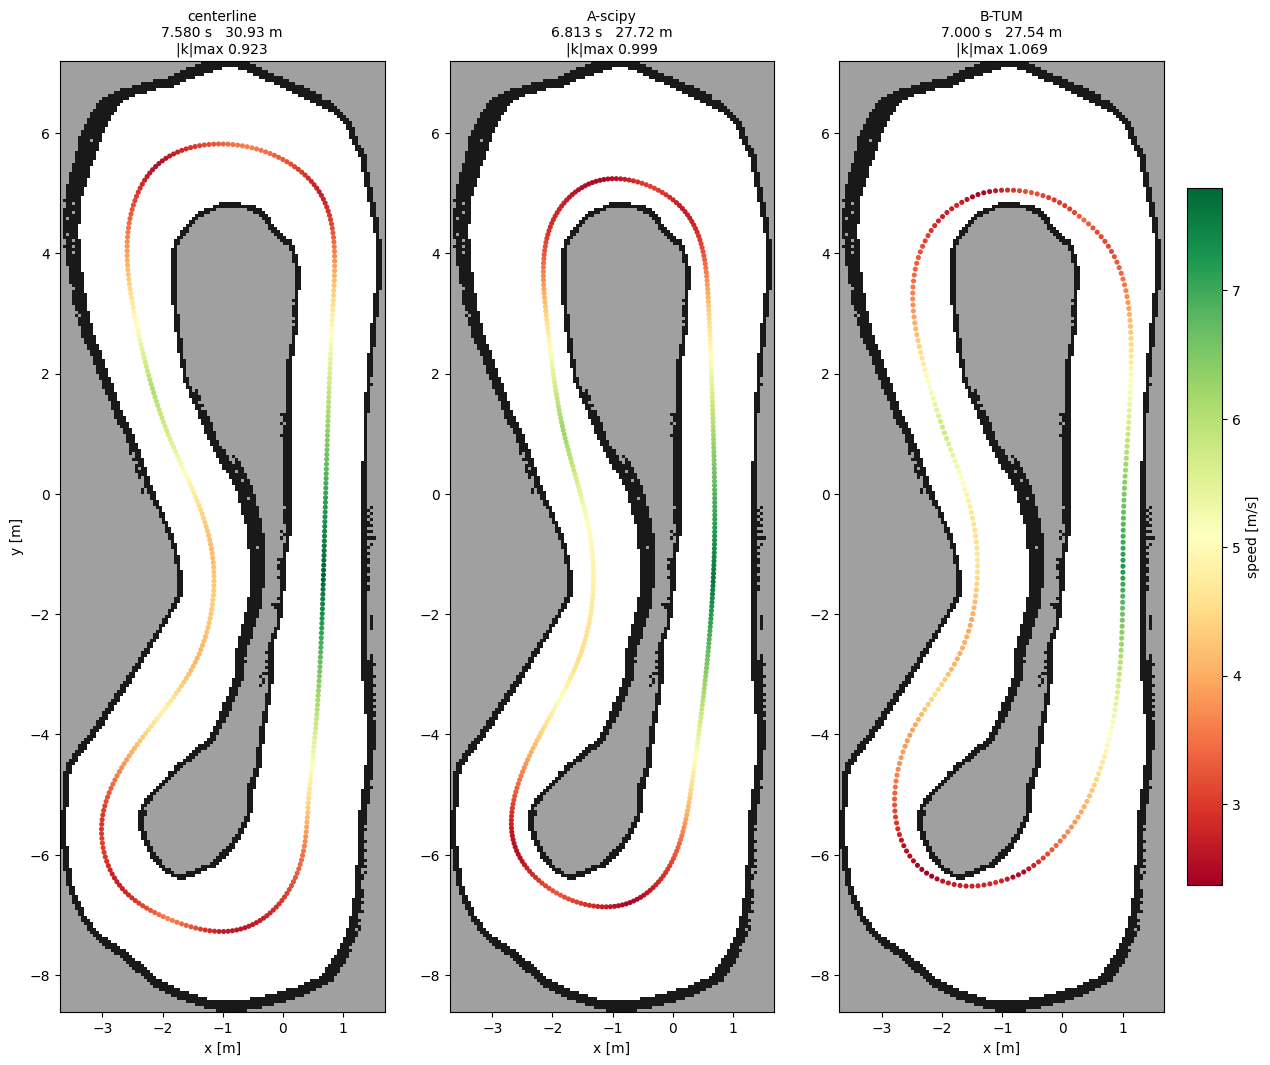

In [7]:
meta = yaml.safe_load(open(MAP.with_suffix(".yaml")))
res_m, (ox, oy, _) = meta["resolution"], meta["origin"]
with open(MAP.with_suffix(".pgm"), "rb") as f:
    f.readline(); Wm, Hm = map(int, f.readline().split()); f.readline()
    img = np.frombuffer(f.read(Wm * Hm), dtype=np.uint8).reshape(Hm, Wm)
rgb = np.zeros((Hm, Wm, 3), np.uint8)
rgb[img == 0] = (25, 25, 25); rgb[img >= 254] = (255, 255, 255); rgb[img == 205] = (160, 160, 160)
extent = [ox, ox + Wm * res_m, oy, oy + Hm * res_m]
close = lambda a: np.append(a, a[0])

rows = [base, res_a, res_b]
vmin = min(r["vx"].min() for r in rows)
vmax = max(r["vx"].max() for r in rows)

fig, axes = plt.subplots(1, 3, figsize=(15, 13))
for ax, r in zip(axes, rows):
    ax.imshow(rgb, extent=extent, origin="upper")
    sc = ax.scatter(r["x"], r["y"], c=r["vx"], cmap="RdYlGn",
                    vmin=vmin, vmax=vmax, s=7, zorder=3)
    ax.set_title(f"{r['label']}\n{r['t']:.3f} s   {r['length']:.2f} m\n"
                 f"|k|max {r['kmax']:.3f}", fontsize=10)
    ax.set_xlabel("x [m]")
axes[0].set_ylabel("y [m]")
fig.colorbar(sc, ax=axes, label="speed [m/s]", fraction=0.03, pad=0.02)
plt.show()

## 7. Side by side

The three overlaid, plus curvature and speed against lap fraction. Lap fraction
rather than metres, because the lines are different lengths -- this puts the same
corner at the same x on all three traces.

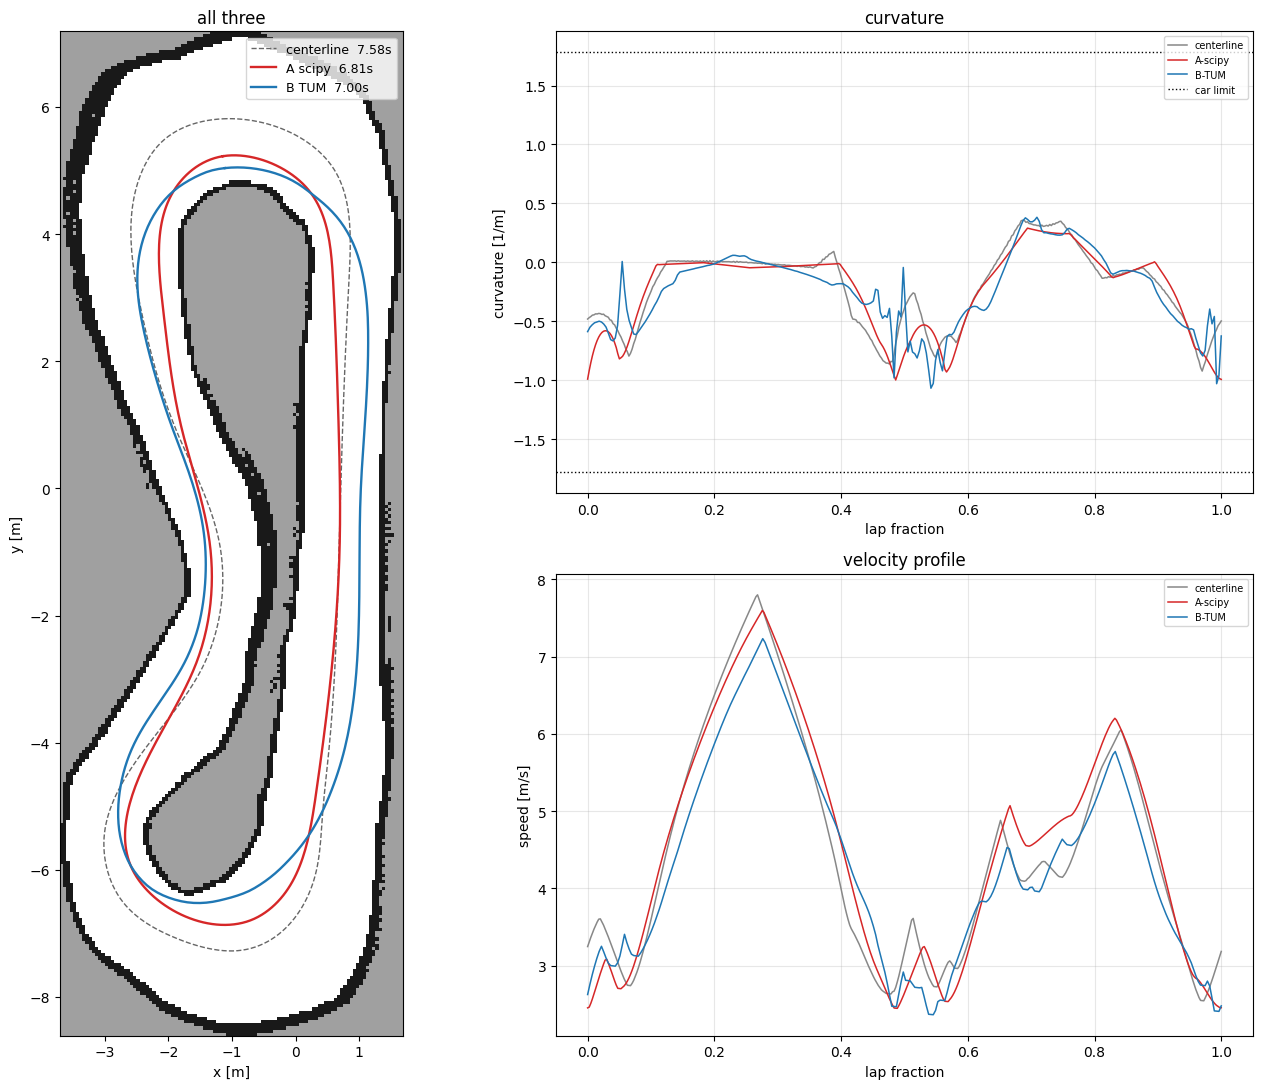

In [8]:
fig = plt.figure(figsize=(14, 11))

axm = fig.add_subplot(1, 2, 1)
axm.imshow(rgb, extent=extent, origin="upper")
axm.plot(close(base["x"]), close(base["y"]), "--", color="#666", lw=1.0,
         label=f"centerline  {base['t']:.2f}s")
axm.plot(close(res_a["x"]), close(res_a["y"]), "-", color="#d62728", lw=1.7,
         label=f"A scipy  {res_a['t']:.2f}s")
axm.plot(close(res_b["x"]), close(res_b["y"]), "-", color="#1f77b4", lw=1.7,
         label=f"B TUM  {res_b['t']:.2f}s")
axm.legend(fontsize=9, loc="upper right")
axm.set_xlabel("x [m]"); axm.set_ylabel("y [m]"); axm.set_title("all three")

a1 = fig.add_subplot(2, 2, 2)
for r, c in ((base, "#888"), (res_a, "#d62728"), (res_b, "#1f77b4")):
    a1.plot(np.linspace(0, 1, len(r["kappa"])), r["kappa"], color=c, lw=1.1, label=r["label"])
a1.axhline(KAPPA_CAR, color="k", ls=":", lw=1, label="car limit")
a1.axhline(-KAPPA_CAR, color="k", ls=":", lw=1)
a1.set_ylabel("curvature [1/m]"); a1.set_xlabel("lap fraction")
a1.legend(fontsize=7); a1.grid(alpha=0.3); a1.set_title("curvature")

a2 = fig.add_subplot(2, 2, 4)
for r, c in ((base, "#888"), (res_a, "#d62728"), (res_b, "#1f77b4")):
    a2.plot(np.linspace(0, 1, len(r["vx"])), r["vx"], color=c, lw=1.1, label=r["label"])
a2.set_ylabel("speed [m/s]"); a2.set_xlabel("lap fraction")
a2.legend(fontsize=7); a2.grid(alpha=0.3); a2.set_title("velocity profile")

plt.tight_layout(); plt.show()

## 8. Export both

Both in the 7-column layout the follower reads, with speed as an 8th column.
Heading is recomputed as `atan2(dy, dx)` — `tph`'s psi convention is rotated by
pi/2 and would be wrong here.

In [9]:
def export(r, filename):
    x, y = r["x"], r["y"]
    s = np.concatenate([[0.0], np.cumsum(r["el"])[:-1]])
    psi = np.arctan2(np.gradient(y), np.gradient(x))
    n = len(x)
    rs = lambda v: np.interp(np.linspace(0, 1, n), np.linspace(0, 1, len(v)), v)
    out = RACELINE_DIR / filename
    np.savetxt(out, np.column_stack([s, x, y, psi, r["kappa"], rs(w_right), rs(w_left), r["vx"]]),
               delimiter=",", fmt="%.5f",
               header="s_m,x_m,y_m,psi_rad,kappa_radpm,w_right_m,w_left_m,v_mps",
               comments="# ")
    print(f"{r['label']:<10} -> {filename}  ({n} points, {r['t']:.3f} s)")
    return out


# The baseline gets a speed column too. Without one the follower falls back to
# its own curvature rule with a different a_lat, and the baseline would be raced
# under a different speed model than the racelines -- not a fair comparison.
path_base = export(base, "centerline_speed.csv")
path_a = export(res_a, "raceline_scipy.csv")
path_b = export(res_b, "raceline_tum.csv")

print("\nrun either:")
for p in (path_base, path_a, path_b):
    print(f"  ros2 launch racer_control pure_pursuit.launch.py path_csv:={p}")

centerline -> centerline_speed.csv  (400 points, 7.580 s)
A-scipy    -> raceline_scipy.csv  (400 points, 6.813 s)
B-TUM      -> raceline_tum.csv  (276 points, 7.000 s)

run either:
  ros2 launch racer_control pure_pursuit.launch.py path_csv:=/home/theflash/Documents/roboracer/raceline/centerline_speed.csv
  ros2 launch racer_control pure_pursuit.launch.py path_csv:=/home/theflash/Documents/roboracer/raceline/raceline_scipy.csv
  ros2 launch racer_control pure_pursuit.launch.py path_csv:=/home/theflash/Documents/roboracer/raceline/raceline_tum.csv


## Tuning

| Knob | Affects | Effect |
|---|---|---|
| `SAFETY_MARGIN` | both | How close to the walls. Raise if localization is shaky. |
| `A_LAT_MAX` | both | **The one that matters.** A guess — measure it. |
| `KAPPA_BOUND` | B | Hard curvature cap inside the QP. |
| `A_LAMBDA` | A | Roughness penalty. Low = shorter, kinkier. High = closer to centerline. |
| `A_SPLINE_S` | A | Smoothing per iteration; interacts strongly with `A_LAMBDA`. |
| `B_STEPSIZE` | B | Raceline resolution. Coarser inflates measured curvature. |

## Next

1. Run both on the car and compare real lap times.
2. **Measure grip** — circles at rising speed until it slides, `a_lat = v²/R`.
   Then set `A_LAT_MAX`, re-run, and the comparison above becomes meaningful.
3. With real grip, replace the flat two-row `ggv` with a velocity-dependent one.